In [1]:
import zipfile

zip_file = "P_Data_Extract_From_World_Development_Indicators.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("world_bank_data")

print("ZIP extraído com sucesso.")

ZIP extraído com sucesso.


In [2]:
import os

os.listdir("world_bank_data")

['38a549e1-0ee0-4eef-9492-2c5c53bad5cb_Data.csv',
 '38a549e1-0ee0-4eef-9492-2c5c53bad5cb_Series - Metadata.csv']

In [3]:
import pandas as pd
import glob

data_file = glob.glob("world_bank_data/*_Data.csv")[0]

df = pd.read_csv(data_file)

df.head()

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Australia,AUS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,82.400000,82.448780,82.500000,82.748780,82.900000,83.200000,83.300000,83.200000,83.051220
1,Australia,AUS,GDP per capita (current US$),NY.GDP.PCAP.CD,56970.361303,50084.444061,54117.547719,57410.173735,55194.758510,51983.452367,60758.904440,65169.519112,65058.377315
2,Australia,AUS,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,5271.933105,5418.436523,5770.690430,5843.647949,5543.378418,5968.003418,7092.134766,6723.982422,6980.385254
3,Australia,AUS,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,6.055000,5.711000,5.592000,5.345000,5.143000,6.394000,5.022000,3.728000,3.668000
4,Australia,AUS,Urban population (% of total population),SP.URB.TOTL.IN.ZS,86.877864,87.016630,87.128093,87.226768,87.301965,87.271347,87.235341,87.334327,87.486696


In [4]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
print(df.shape)
print(df.columns.tolist())
print(df["Series Name"].unique())
print(df.isnull().sum())

(131, 13)
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']
['Life expectancy at birth, total (years)' 'GDP per capita (current US$)'
 'Current health expenditure per capita (current US$)'
 'Unemployment, total (% of total labor force) (modeled ILO estimate)'
 'Urban population (% of total population)'
 'Individuals using the Internet (% of population)' nan]
Country Name     3
Country Code     5
Series Name      5
Series Code      5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
2021 [YR2021]    5
2022 [YR2022]    5
2023 [YR2023]    5
dtype: int64


In [6]:
df = df.dropna(how="all").copy()

print(df.shape)
print(df["Series Name"].unique())
print(df.isnull().sum())

(128, 13)
['Life expectancy at birth, total (years)' 'GDP per capita (current US$)'
 'Current health expenditure per capita (current US$)'
 'Unemployment, total (% of total labor force) (modeled ILO estimate)'
 'Urban population (% of total population)'
 'Individuals using the Internet (% of population)' nan]
Country Name     0
Country Code     2
Series Name      2
Series Code      2
2015 [YR2015]    2
2016 [YR2016]    2
2017 [YR2017]    2
2018 [YR2018]    2
2019 [YR2019]    2
2020 [YR2020]    2
2021 [YR2021]    2
2022 [YR2022]    2
2023 [YR2023]    2
dtype: int64


In [7]:
df[df["Series Name"].isna()]

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
129,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,Last Updated: 07/13/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.dropna(subset=["Series Name"]).reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(126, 13)
Country Name     0
Country Code     0
Series Name      0
Series Code      0
2015 [YR2015]    0
2016 [YR2016]    0
2017 [YR2017]    0
2018 [YR2018]    0
2019 [YR2019]    0
2020 [YR2020]    0
2021 [YR2021]    0
2022 [YR2022]    0
2023 [YR2023]    0
dtype: int64


# Predicting Life Expectancy Using World Development Indicators

## 1. Business Understanding

Life expectancy is an important indicator of a country's overall health and development. This project analyses data from the World Bank's World Development Indicators to understand how economic, healthcare, employment, urbanisation, and digital-access factors relate to life expectancy.

The main objective is to train a machine learning model that predicts life expectancy at birth using selected socioeconomic indicators.

### Business Questions

1. Which socioeconomic indicators have the strongest relationship with life expectancy?
2. What unusual or unexpected patterns can be identified across countries and years?
3. How accurately can a machine learning model predict life expectancy?
4. What life expectancy would the model predict for a hypothetical country with a specific socioeconomic profile?

In [9]:
year_columns = [
    column for column in df.columns
    if column.startswith(("2015", "2016", "2017", "2018", "2019",
                          "2020", "2021", "2022", "2023"))
]

df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Series Name"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].str[:4].astype(int)

df_model = df_long.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

df_model.columns.name = None

print(df_model.shape)
df_model.head()

(189, 9)


,Country Name,Country Code,Year,Current health expenditure per capita (current US$),GDP per capita (current US$),Individuals using the Internet (% of population),"Life expectancy at birth, total (years)","Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,Australia,AUS,2015,5271.933105,56970.361303,84.560515,82.40000,6.055,86.877864
1,Australia,AUS,2016,5418.436523,50084.444061,86.540001,82.44878,5.711,87.016630
2,Australia,AUS,2017,5770.690430,54117.547719,86.545049,82.50000,5.592,87.128093
3,Australia,AUS,2018,5843.647949,57410.173735,90.008202,82.74878,5.345,87.226768
4,Australia,AUS,2019,5543.378418,55194.758510,93.609901,82.90000,5.143,87.301965


In [10]:
print(df_model.shape)
print(df_model.columns.tolist())
print(df_model.isnull().sum())

(189, 9)
['Country Name', 'Country Code', 'Year', 'Current health expenditure per capita (current US$)', 'GDP per capita (current US$)', 'Individuals using the Internet (% of population)', 'Life expectancy at birth, total (years)', 'Unemployment, total (% of total labor force) (modeled ILO estimate)', 'Urban population (% of total population)']
Country Name                                                           0
Country Code                                                           0
Year                                                                   0
Current health expenditure per capita (current US$)                    0
GDP per capita (current US$)                                           0
Individuals using the Internet (% of population)                       0
Life expectancy at birth, total (years)                                0
Unemployment, total (% of total labor force) (modeled ILO estimate)    0
Urban population (% of total population)                             

In [11]:
df_model = df_model.rename(columns={
    "Country Name": "country",
    "Country Code": "country_code",
    "Year": "year",
    "Current health expenditure per capita (current US$)": "health_expenditure",
    "GDP per capita (current US$)": "gdp_per_capita",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
})

df_model.head()

,country,country_code,year,health_expenditure,gdp_per_capita,internet_usage,life_expectancy,unemployment,urban_population
0,Australia,AUS,2015,5271.933105,56970.361303,84.560515,82.40000,6.055,86.877864
1,Australia,AUS,2016,5418.436523,50084.444061,86.540001,82.44878,5.711,87.016630
2,Australia,AUS,2017,5770.690430,54117.547719,86.545049,82.50000,5.592,87.128093
3,Australia,AUS,2018,5843.647949,57410.173735,90.008202,82.74878,5.345,87.226768
4,Australia,AUS,2019,5543.378418,55194.758510,93.609901,82.90000,5.143,87.301965


## 2. Data Understanding

The dataset was obtained from the World Bank's World Development Indicators database. It contains socioeconomic and health indicators for 21 countries across multiple years.

Each row in the original dataset represents one indicator for one country, while the year columns contain the corresponding values.

The selected indicators are:

- Life expectancy at birth, total (years)
- GDP per capita (current US$)
- Current health expenditure per capita (current US$)
- Unemployment, total (% of total labor force)
- Urban population (% of total population)
- Individuals using the Internet (% of population)

Life expectancy will be used as the target variable. The remaining indicators will be evaluated as potential features for the predictive model.

In [12]:
df.head()

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Australia,AUS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,82.400000,82.448780,82.500000,82.748780,82.900000,83.200000,83.300000,83.200000,83.051220
1,Australia,AUS,GDP per capita (current US$),NY.GDP.PCAP.CD,56970.361303,50084.444061,54117.547719,57410.173735,55194.758510,51983.452367,60758.904440,65169.519112,65058.377315
2,Australia,AUS,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,5271.933105,5418.436523,5770.690430,5843.647949,5543.378418,5968.003418,7092.134766,6723.982422,6980.385254
3,Australia,AUS,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,6.055000,5.711000,5.592000,5.345000,5.143000,6.394000,5.022000,3.728000,3.668000
4,Australia,AUS,Urban population (% of total population),SP.URB.TOTL.IN.ZS,86.877864,87.016630,87.128093,87.226768,87.301965,87.271347,87.235341,87.334327,87.486696


## 3. Data Preparation

The original dataset stores each indicator in a separate row and each year in a separate column. For the analysis and machine learning model, the data will be reshaped so that each row represents one country in one year, with the indicators stored in separate columns.

In [13]:
id_columns = [
    "Country Name",
    "Country Code",
    "Series Name",
    "Series Code"
]

year_columns = [
    column for column in df.columns
    if column.startswith(("19", "20"))
]

df_long = df.melt(
    id_vars=id_columns,
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = (
    df_long["Year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

df_model = df_long.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Code",
    values="Value"
).reset_index()

df_model.columns.name = None

df_model = df_model.rename(
    columns={
        "SP.DYN.LE00.IN": "Life Expectancy",
        "NY.GDP.PCAP.CD": "GDP per Capita",
        "SH.XPD.CHEX.PC.CD": "Health Expenditure per Capita",
        "SL.UEM.TOTL.ZS": "Unemployment",
        "SP.URB.TOTL.IN.ZS": "Urban Population",
        "IT.NET.USER.ZS": "Internet Usage"
    }
)

df_model.head()

,Country Name,Country Code,Year,Internet Usage,GDP per Capita,Health Expenditure per Capita,Unemployment,Life Expectancy,Urban Population
0,Australia,AUS,2015,84.560515,56970.361303,5271.933105,6.055,82.40000,86.877864
1,Australia,AUS,2016,86.540001,50084.444061,5418.436523,5.711,82.44878,87.016630
2,Australia,AUS,2017,86.545049,54117.547719,5770.690430,5.592,82.50000,87.128093
3,Australia,AUS,2018,90.008202,57410.173735,5843.647949,5.345,82.74878,87.226768
4,Australia,AUS,2019,93.609901,55194.758510,5543.378418,5.143,82.90000,87.301965


In [14]:
df_model.columns = [
    "country",
    "country_code",
    "year",
    "internet_usage",
    "gdp_per_capita",
    "health_expenditure",
    "unemployment",
    "life_expectancy",
    "urban_population"
]

df_model.head()

,country,country_code,year,internet_usage,gdp_per_capita,health_expenditure,unemployment,life_expectancy,urban_population
0,Australia,AUS,2015,84.560515,56970.361303,5271.933105,6.055,82.40000,86.877864
1,Australia,AUS,2016,86.540001,50084.444061,5418.436523,5.711,82.44878,87.016630
2,Australia,AUS,2017,86.545049,54117.547719,5770.690430,5.592,82.50000,87.128093
3,Australia,AUS,2018,90.008202,57410.173735,5843.647949,5.345,82.74878,87.226768
4,Australia,AUS,2019,93.609901,55194.758510,5543.378418,5.143,82.90000,87.301965


In [15]:
print(df_model.info())
print("\nDuplicate rows:", df_model.duplicated().sum())

df_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             189 non-null    object 
 1   country_code        189 non-null    object 
 2   year                189 non-null    int64  
 3   internet_usage      189 non-null    float64
 4   gdp_per_capita      189 non-null    float64
 5   health_expenditure  189 non-null    float64
 6   unemployment        189 non-null    float64
 7   life_expectancy     189 non-null    float64
 8   urban_population    189 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 13.4+ KB
None

Duplicate rows: 0


,year,internet_usage,gdp_per_capita,health_expenditure,unemployment,life_expectancy,urban_population
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000
mean,2019.000000,88.591868,50897.951927,5362.953841,6.852439,81.947834,79.970462
std,2.588847,7.799076,19517.657715,2315.274686,4.029498,1.291934,8.550354
min,2015.000000,58.141735,17886.733165,1481.419678,2.351000,76.329268,61.095125
25%,2017.000000,85.199997,40408.284857,4128.207520,4.355000,81.324390,77.519443
50%,2019.000000,90.424550,48716.409890,5111.817383,5.592000,81.858537,81.401895
75%,2021.000000,93.937103,57976.628204,6219.129883,7.759000,82.758537,87.000000
max,2023.000000,99.000004,113122.130766,13473.193359,24.981000,84.560000,95.322168


# World Development and Life Expectancy

## Business Understanding

This project explores the economic, technological, health, and social factors associated with life expectancy across 21 developed countries between 2015 and 2023.

The analysis addresses the following questions:

1. Which features are most strongly associated with life expectancy?
2. What unusual or unexpected patterns can be identified across countries and years?
3. How accurately can a machine learning model predict life expectancy?
4. What life expectancy does the trained model predict for a new hypothetical scenario?

## Data Understanding

The dataset was obtained from the World Bank's World Development Indicators database. It contains 189 country-year observations and includes life expectancy as the target variable, together with five potential predictor variables: GDP per capita, health expenditure per capita, internet usage, unemployment, and urban population.

## Exploratory Data Analysis

The distributions of the numerical variables are examined to identify their ranges, skewness, and potential outliers.

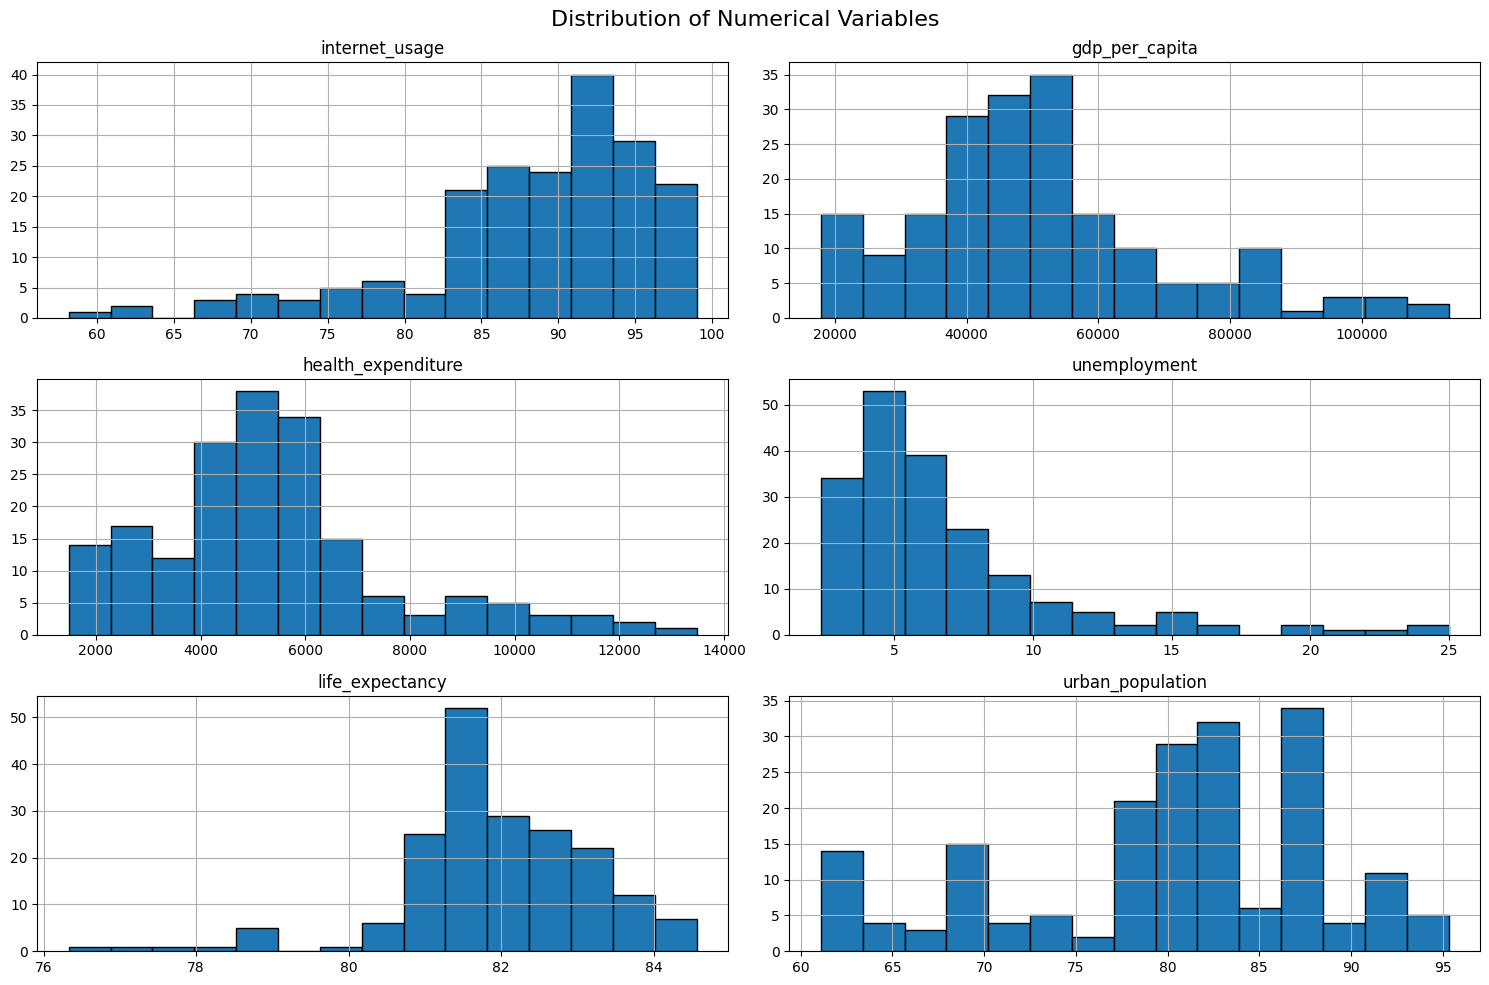

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = [
    "internet_usage",
    "gdp_per_capita",
    "health_expenditure",
    "unemployment",
    "life_expectancy",
    "urban_population"
]

df_model[numeric_columns].hist(
    bins=15,
    figsize=(15, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

### Distribution Insights

The distributions reveal substantial differences between the country-year observations. Internet usage is generally high, although a small number of observations have considerably lower values. GDP per capita and health expenditure are right-skewed, indicating that a limited number of observations report particularly high economic resources and healthcare spending.

Unemployment is also right-skewed, with most observations below 10% and a small number of considerably higher values. Life expectancy is concentrated mainly between 81 and 84 years, although a few observations fall below this range. Urban population shows wider variation, indicating meaningful differences in the level of urbanisation across the selected countries.

These values are plausible country-level observations and will therefore be retained rather than automatically treated as errors or removed as outliers.

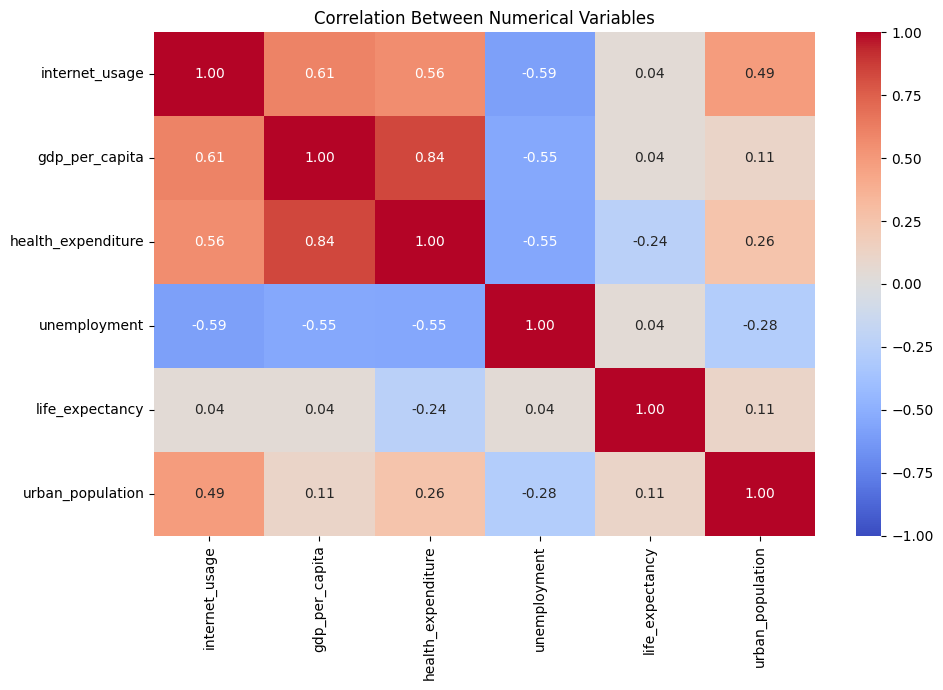

In [17]:
correlation_matrix = df_model[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

### Correlation Insights

The correlation matrix reveals that no individual predictor has a strong linear relationship with life expectancy in this dataset. Health expenditure has the largest absolute correlation with life expectancy (-0.24), while urban population has a weak positive correlation (0.11). Internet usage, GDP per capita, and unemployment show correlations close to zero.

A notable and unexpected result is that greater healthcare expenditure is not directly associated with higher life expectancy across these observations. This does not imply that healthcare spending reduces life expectancy. Correlation does not establish causation, and the selected countries may differ in demographic structure, healthcare costs, and other factors not included in the dataset.

GDP per capita and health expenditure have a strong positive correlation of 0.84. This indicates that wealthier countries generally spend more on healthcare and also suggests potential multicollinearity between these predictors.

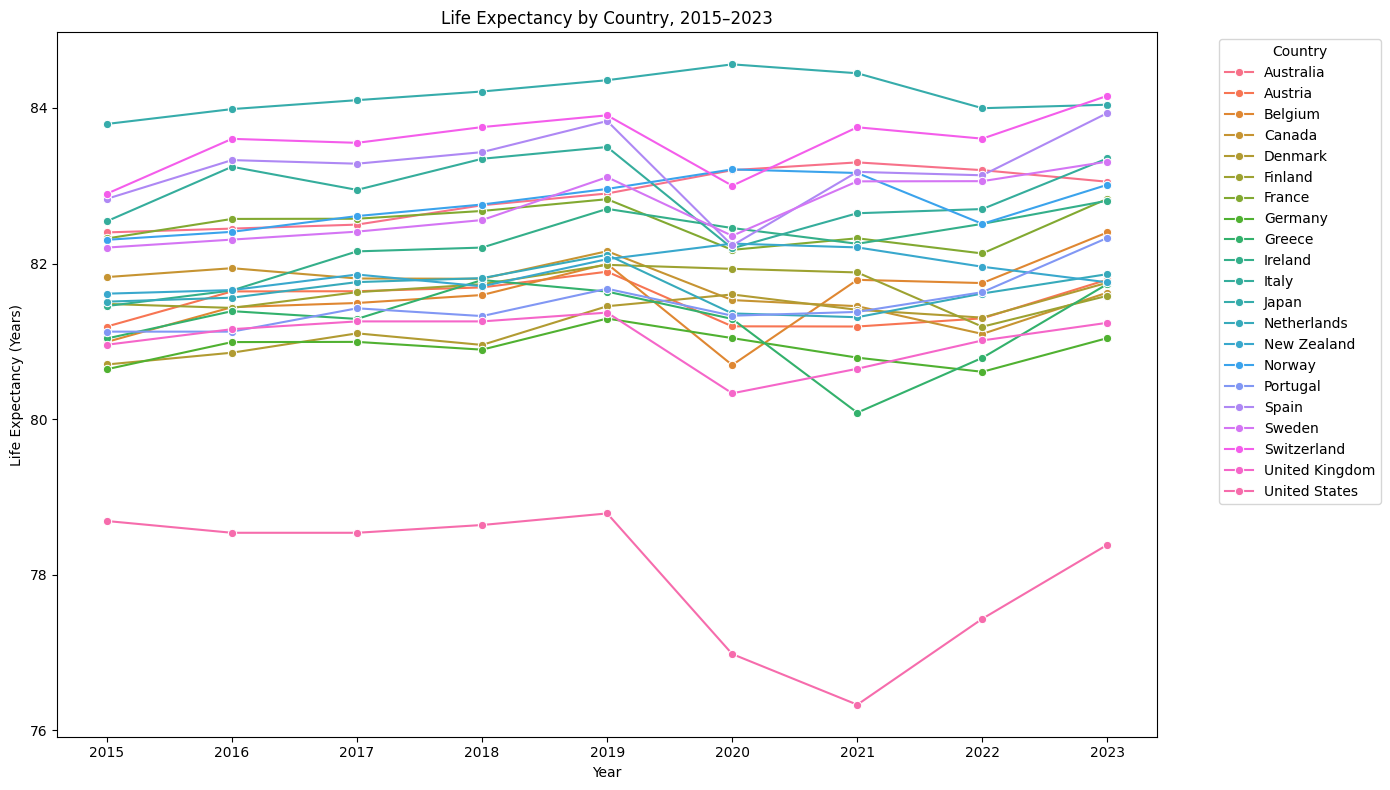

In [37]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_model,
    x="year",
    y="life_expectancy",
    hue="country",
    marker="o"
)

plt.title("Life Expectancy by Country, 2015–2023")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig(
    "life_expectancy_by_country.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Life Expectancy Trends

Life expectancy remained relatively stable for most countries between 2015 and 2023, generally ranging from approximately 80 to 85 years. However, differences between countries are visible throughout the period.

A noticeable decline appears for several countries around 2020 and 2021, followed by a partial recovery in subsequent years. The United States stands out with consistently lower life expectancy than the other countries included in the dataset and shows the sharpest decline during this period.

These patterns suggest that country-level socioeconomic indicators may help explain differences in life expectancy.

In [19]:
print("Dataset shape:", df_model.shape)
print("\nData types:")
print(df_model.dtypes)

print("\nMissing values:")
print(df_model.isnull().sum())

print("\nDuplicate rows:")
print(df_model.duplicated().sum())

Dataset shape: (189, 9)

Data types:
country                object
country_code           object
year                    int64
internet_usage        float64
gdp_per_capita        float64
health_expenditure    float64
unemployment          float64
life_expectancy       float64
urban_population      float64
dtype: object

Missing values:
country               0
country_code          0
year                  0
internet_usage        0
gdp_per_capita        0
health_expenditure    0
unemployment          0
life_expectancy       0
urban_population      0
dtype: int64

Duplicate rows:
0


### Data Quality Assessment

The transformed dataset contains 189 observations and 9 variables. Each observation represents one country in one year.

The assessment identified no missing values and no duplicate rows. Therefore, dropping observations or applying an imputation method was not necessary. The six indicators are stored as numeric variables, while the country identifiers are stored as text and the year is stored as an integer.

The country and country code columns will be retained for analysis and visualisation but will not be included as predictive features in the initial machine learning model.

In [20]:
numeric_columns = [
    "internet_usage",
    "gdp_per_capita",
    "health_expenditure",
    "unemployment",
    "life_expectancy",
    "urban_population"
]

df_model[numeric_columns].describe().round(2)

,internet_usage,gdp_per_capita,health_expenditure,unemployment,life_expectancy,urban_population
count,189.00,189.00,189.00,189.00,189.00,189.00
mean,88.59,50897.95,5362.95,6.85,81.95,79.97
std,7.80,19517.66,2315.27,4.03,1.29,8.55
min,58.14,17886.73,1481.42,2.35,76.33,61.10
25%,85.20,40408.28,4128.21,4.36,81.32,77.52
50%,90.42,48716.41,5111.82,5.59,81.86,81.40
75%,93.94,57976.63,6219.13,7.76,82.76,87.00
max,99.00,113122.13,13473.19,24.98,84.56,95.32


### Distribution of the Numeric Variables

Distribution plots are used to understand the range, concentration, skewness, and potential outliers of the numeric variables before building the predictive model.

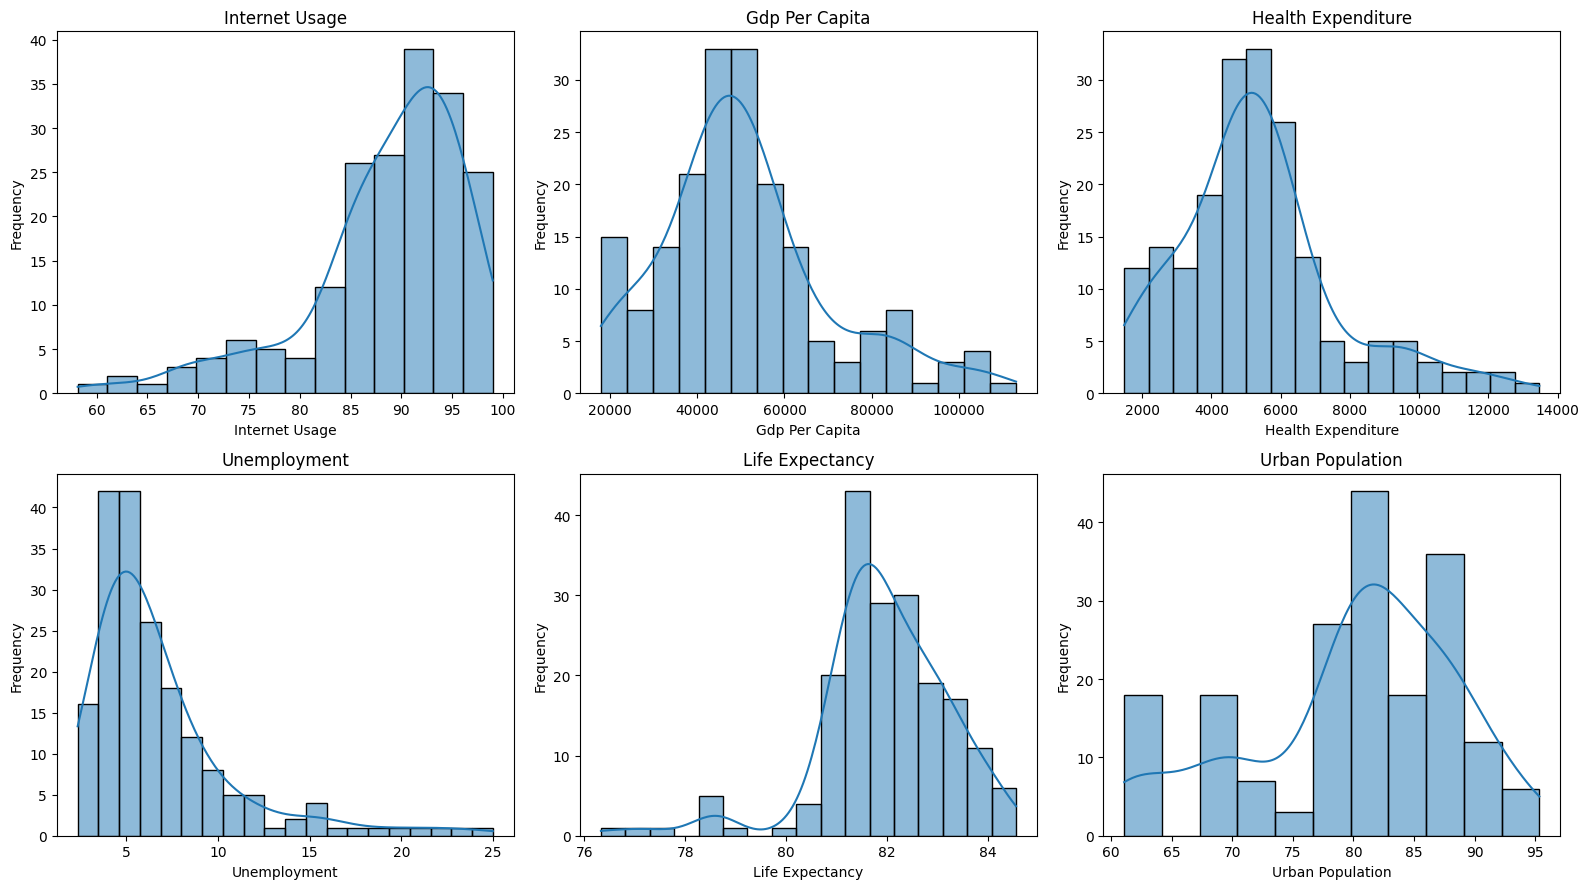

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for column, axis in zip(numeric_columns, axes.flatten()):
    sns.histplot(
        data=df_model,
        x=column,
        kde=True,
        ax=axis
    )
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel(column.replace("_", " ").title())
    axis.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

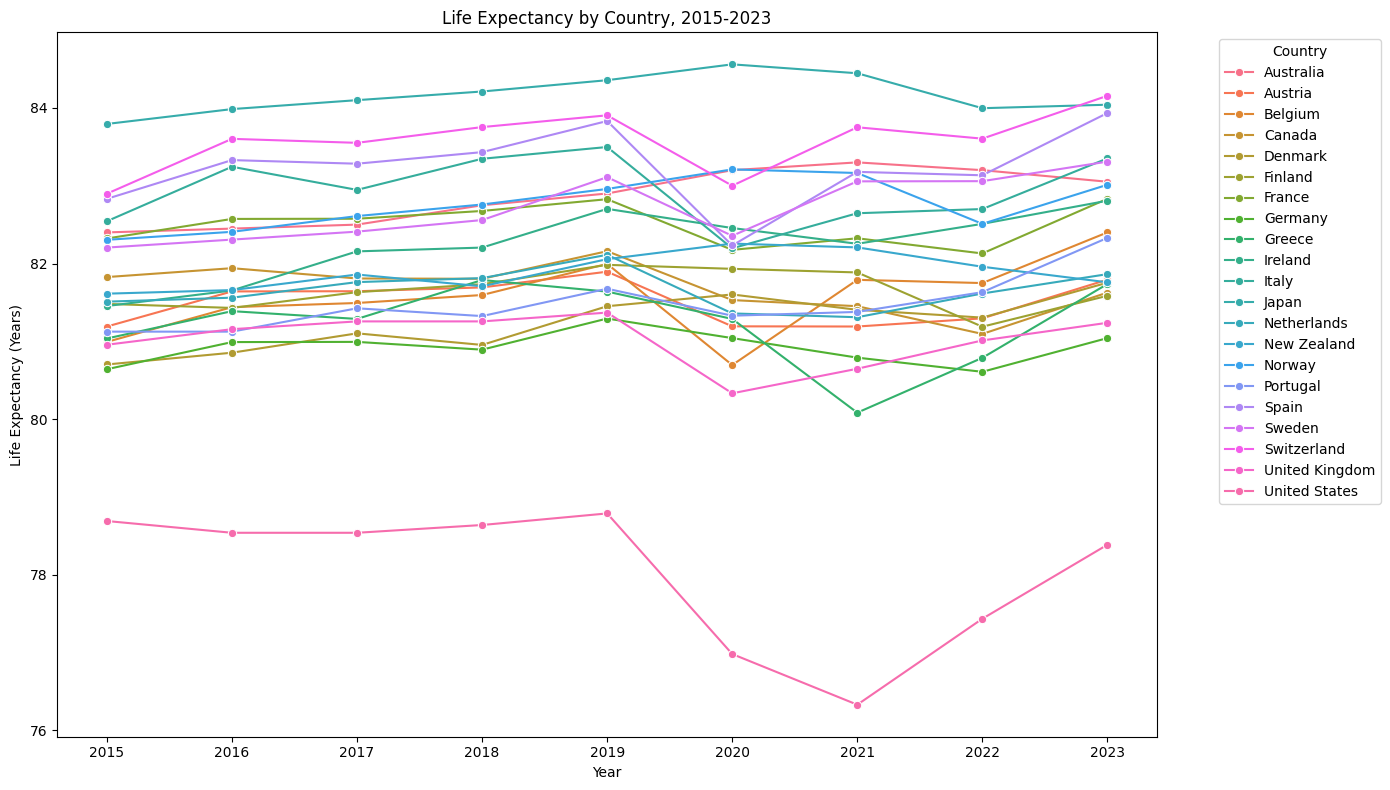

In [22]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_model,
    x="year",
    y="life_expectancy",
    hue="country",
    marker="o"
)

plt.title("Life Expectancy by Country, 2015-2023")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [23]:
life_expectancy_change = (
    df_model
    .sort_values(["country", "year"])
    .assign(
        annual_change=lambda data: (
            data.groupby("country")["life_expectancy"].diff()
        )
    )
)

largest_declines = (
    life_expectancy_change
    .nsmallest(
        10,
        "annual_change"
    )[
        [
            "country",
            "year",
            "life_expectancy",
            "annual_change"
        ]
    ]
)

largest_declines

,country,year,life_expectancy,annual_change
185,United States,2020,76.980488,-1.807317
149,Spain,2020,82.231707,-1.600000
95,Italy,2020,82.195122,-1.302439
23,Belgium,2020,80.695122,-1.300000
78,Greece,2021,80.082927,-1.204878
176,United Kingdom,2020,80.331756,-1.037366
167,Switzerland,2020,83.000000,-0.904878
158,Sweden,2020,82.356098,-0.753659
113,Netherlands,2020,81.358537,-0.753659
14,Austria,2020,81.192683,-0.702439


### An Unusual Temporal Pattern

Eight of the ten largest annual declines in life expectancy occurred in 2020. The largest decline was observed in the United States, where life expectancy fell by approximately 1.81 years. Spain, Italy, and Belgium also recorded declines greater than one year in 2020.

Greece was an exception to the dominant pattern, recording its largest decline in 2021. These results reveal that the year of observation may contain important predictive information that is not captured by the five socioeconomic indicators alone.


## Data Preparation

No missing values or duplicate observations were identified. The numerical predictor variables are used without removing valid extreme observations. Country names and country codes are identifiers and are therefore excluded from the initial model.

The year is included as a predictor because the exploratory analysis identified meaningful temporal changes in life expectancy.

In [24]:
feature_columns = [
    "year",
    "internet_usage",
    "gdp_per_capita",
    "health_expenditure",
    "unemployment",
    "urban_population"
]

target_column = "life_expectancy"

X = df_model[feature_columns]
y = df_model[target_column]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (189, 6)
Target shape: (189,)


,year,internet_usage,gdp_per_capita,health_expenditure,unemployment,urban_population
0,2015,84.560515,56970.361303,5271.933105,6.055,86.877864
1,2016,86.540001,50084.444061,5418.436523,5.711,87.016630
2,2017,86.545049,54117.547719,5770.690430,5.592,87.128093
3,2018,90.008202,57410.173735,5843.647949,5.345,87.226768
4,2019,93.609901,55194.758510,5543.378418,5.143,87.301965


## 4. Modeling

The numeric socioeconomic indicators and year are used as predictive features, while life expectancy is used as the target variable. The data is divided into training and testing sets so that the model can be evaluated using observations that were not used during training.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training feature matrix: (151, 6)
Testing feature matrix: (38, 6)
Training target: (151,)
Testing target: (38,)


In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed.")
print("Number of predictions:", len(y_pred))

Model training completed.
Number of predictions: 38


## Modeling

A linear regression model is used as an interpretable baseline. The dataset is divided into training and test sets, with 80% of the observations used for training and 20% reserved for evaluation. A fixed random state is used to ensure that the results are reproducible.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Training observations:", X_train.shape[0])
print("Test observations:", X_test.shape[0])

Training observations: 151
Test observations: 38


## Model Evaluation

The model is evaluated using three regression metrics:

- Mean Absolute Error (MAE): the average absolute difference between the predicted and actual life expectancy.
- Root Mean Squared Error (RMSE): similar to MAE, but penalises larger prediction errors more strongly.
- R-squared (R²): the proportion of variation in life expectancy explained by the model.

In [28]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"MAE: {mae_linear:.3f} years")
print(f"RMSE: {rmse_linear:.3f} years")
print(f"R²: {r2_linear:.3f}")

MAE: 0.910 years
RMSE: 1.091 years
R²: 0.204


### Linear Regression Results

The linear regression model achieved a Mean Absolute Error of 0.910 years. This means that its predictions differ from the actual life expectancy by approximately 0.91 years on average.

The Root Mean Squared Error was 1.091 years. Because RMSE penalises larger errors more strongly, its higher value indicates that some observations have prediction errors greater than the average.

The R-squared score was 0.204, meaning that the model explains approximately 20.4% of the variation in life expectancy in the test data. Therefore, the model provides some predictive value, but most of the variation remains unexplained. This suggests that the relationship may not be fully linear or that other relevant factors are not included in the dataset.

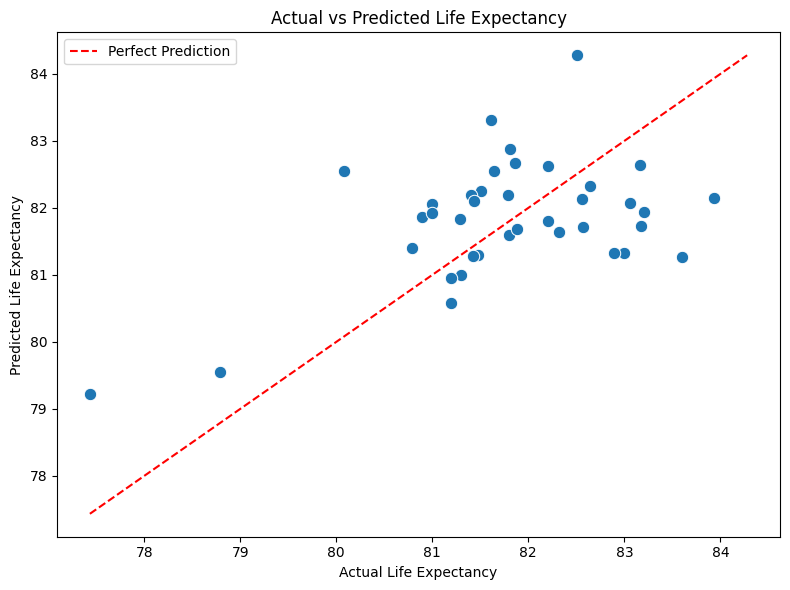

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_linear,
    s=80
)

minimum_value = min(y_test.min(), y_pred_linear.min())
maximum_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Life Expectancy")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Model Evaluation

The model is evaluated on the test data using Mean Absolute Error, Root Mean Squared Error, and the R-squared score.

- Mean Absolute Error measures the average absolute difference between actual and predicted life expectancy.
- Root Mean Squared Error gives greater weight to larger prediction errors.
- R-squared measures the proportion of variation in life expectancy explained by the model.


In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} years")
print(f"Root Mean Squared Error: {rmse:.2f} years")
print(f"R-squared Score: {r2:.3f}")

Mean Absolute Error: 0.45 years
Root Mean Squared Error: 0.57 years
R-squared Score: 0.781


### Evaluation Results

The Random Forest model achieved a Mean Absolute Error of 0.45 years, meaning that its predictions differ from the actual life expectancy values by approximately 0.45 years on average.

The Root Mean Squared Error was 0.57 years. This indicates that larger prediction errors were also relatively limited.

The R-squared score was 0.781, meaning that the model explained approximately 78.1% of the variation in life expectancy within the test data. Overall, the model demonstrates good predictive performance, although some variation remains unexplained.

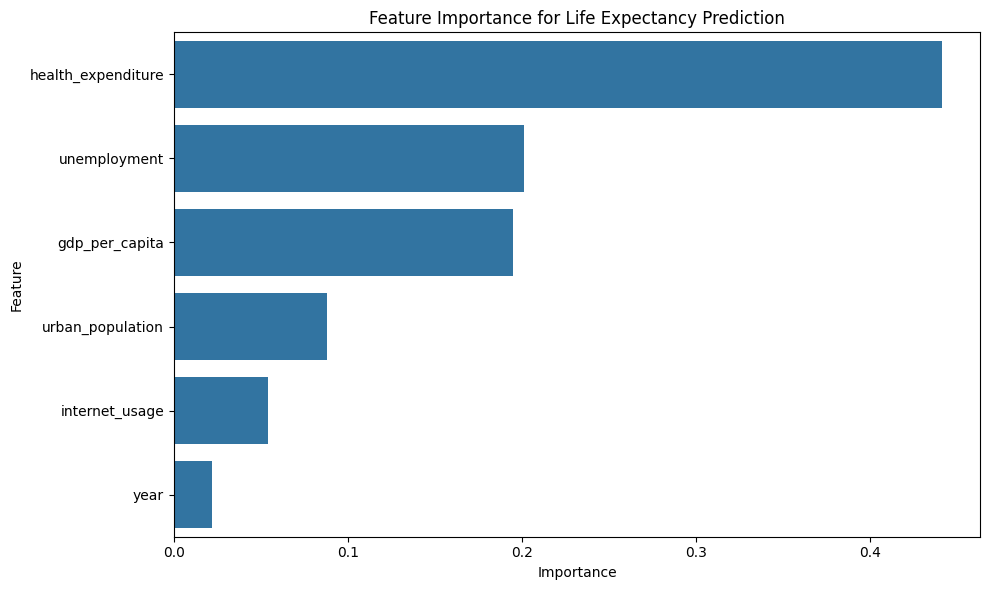

,Feature,Importance
3,health_expenditure,0.440895
4,unemployment,0.200787
2,gdp_per_capita,0.194827
5,urban_population,0.087806
1,internet_usage,0.054040
0,year,0.021646


In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Life Expectancy Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feature_importance

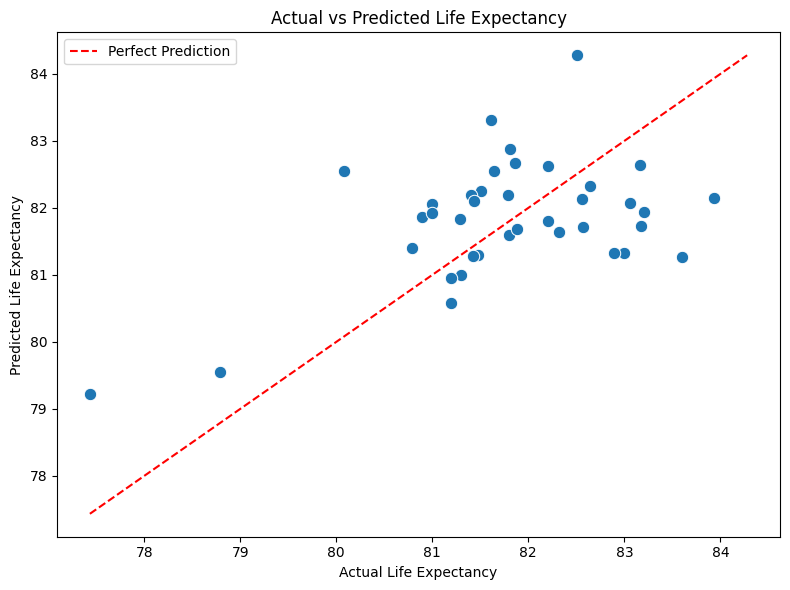

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_linear,
    s=80
)

minimum_value = min(y_test.min(), y_pred_linear.min())
maximum_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Life Expectancy")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

Permutation importance is used to estimate how much each feature contributes to the model's predictive performance. This method measures how much the model's score decreases when the values of one feature are randomly rearranged. A larger decrease indicates that the feature is more important to the model.

In [33]:
import pandas as pd

from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    linear_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2"
)

feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": permutation_results.importances_mean
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,health_expenditure,3.194933
1,gdp_per_capita,3.036994
2,urban_population,0.121838
3,internet_usage,0.075119
4,year,0.033573
5,unemployment,-0.002666


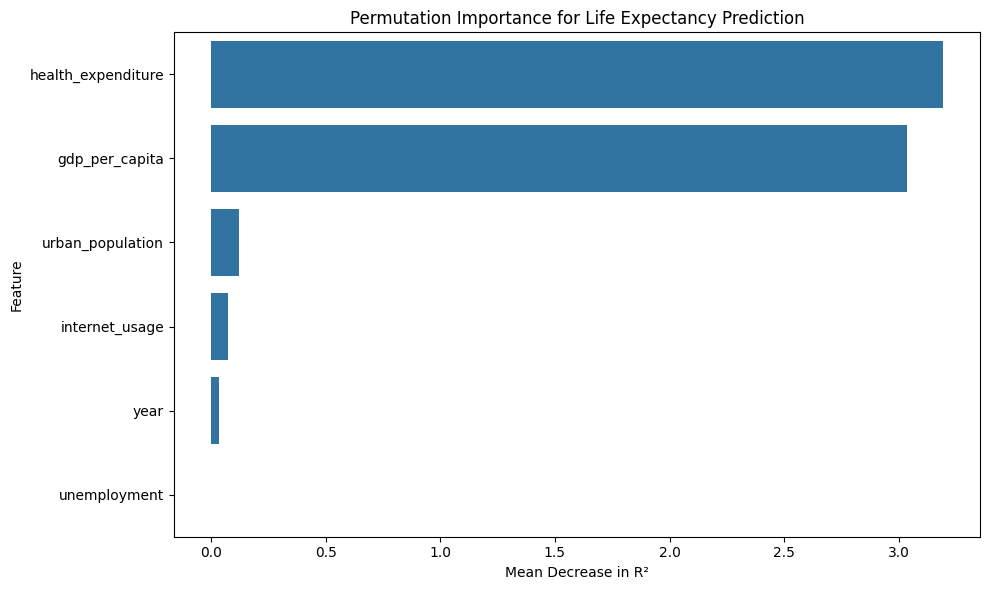

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Permutation Importance for Life Expectancy Prediction")
plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Results

Health expenditure and GDP per capita were the two most influential features in the linear regression model. Their permutation importance values were substantially higher than those of the other predictors.

However, these results should be interpreted carefully because GDP per capita and health expenditure are strongly correlated with each other. Their importance reflects the model's dependence on these variables for prediction, but it does not establish that either variable directly causes changes in life expectancy.

Urban population, internet usage, and year made smaller contributions to the model. Unemployment had a permutation importance close to zero, indicating that it provided little additional predictive value in this model.

## Predictive Scenario

Consider a hypothetical developed country in 2023 with high internet access, a strong economy, substantial healthcare expenditure, moderate unemployment, and a highly urbanised population. The trained model is used to estimate the life expectancy associated with this scenario.

In [35]:
hypothetical_scenario = pd.DataFrame({
    "year": [2023],
    "internet_usage": [95.0],
    "gdp_per_capita": [55000.0],
    "health_expenditure": [6000.0],
    "unemployment": [5.0],
    "urban_population": [85.0]
})

predicted_life_expectancy = linear_model.predict(
    hypothetical_scenario
)[0]

print(
    "Predicted life expectancy: "
    f"{predicted_life_expectancy:.2f} years"
)

Predicted life expectancy: 82.25 years


### Scenario Prediction

For this hypothetical developed country, the model predicts a life expectancy of 82.25 years.

This prediction is consistent with the central range observed in the dataset. However, it should be interpreted as an estimate rather than an exact outcome. The model has a Mean Absolute Error of 0.91 years and explains only 20.4% of the variation in the test data. In addition, the scenario does not include other potentially relevant factors such as demographics, lifestyle, healthcare quality, inequality, or environmental conditions.

## Conclusion

This project investigated the factors associated with life expectancy across 21 developed countries between 2015 and 2023.

GDP per capita and health expenditure were the features with the greatest influence on the model's predictions. However, these variables were also strongly correlated, so their individual importance should be interpreted carefully.

The exploratory analysis identified a notable temporal pattern: eight of the ten largest annual declines in life expectancy occurred in 2020. The United States recorded the largest decline, followed by Spain, Italy, and Belgium.

The linear regression model achieved a Mean Absolute Error of 0.91 years, a Root Mean Squared Error of 1.09 years, and an R-squared score of 0.204. These results indicate that the selected variables provide some predictive value, but most variation in life expectancy remains unexplained.

For the hypothetical scenario, the model predicted a life expectancy of 82.25 years. The prediction demonstrates how the model can be applied to new data, while also highlighting the importance of recognising its limitations.

In [39]:
import os
import zipfile

output_zip = "Udacity_Project.zip"

excluded_items = {
    output_zip,
    "P_Data_Extract_From_World_Development_Indicators.zip"
}

with zipfile.ZipFile(
    output_zip,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:
    for root, directories, files in os.walk("."):
        directories[:] = [
            directory
            for directory in directories
            if directory not in {
                ".ipynb_checkpoints",
                "__pycache__"
            }
        ]

        for file_name in files:
            file_path = os.path.join(root, file_name)
            archive_name = os.path.relpath(file_path, ".")

            if (
                file_name not in excluded_items
                and not file_name.endswith(".zip")
            ):
                zip_file.write(file_path, archive_name)

print(f"Created: {output_zip}")

PermissionError: [Errno 13] Permission denied: '.\\NTUSER.DAT'